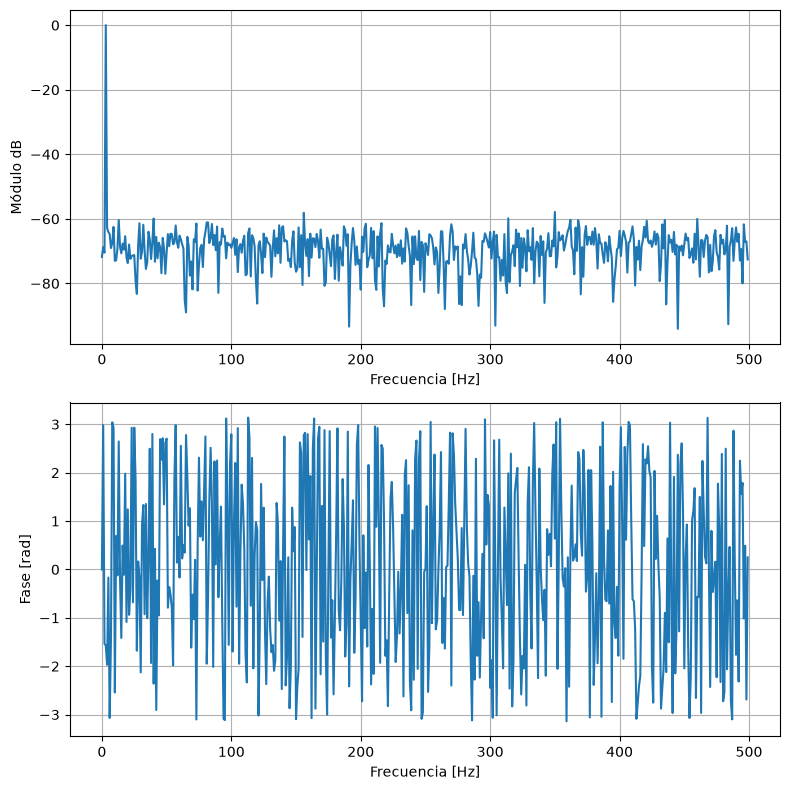

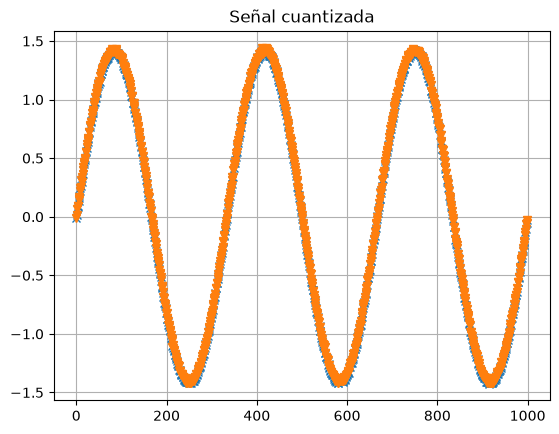

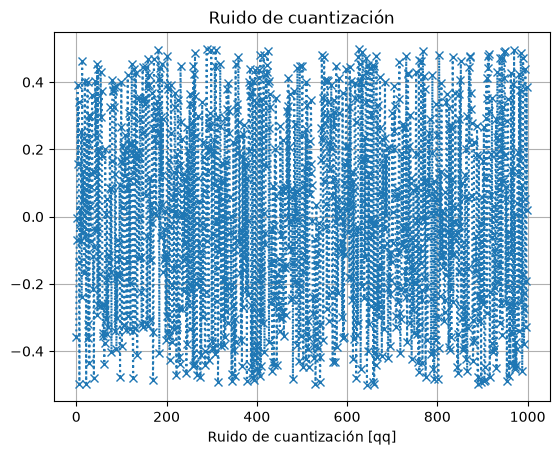

Media del ruido de cuantizacion:
-1.4049830856096977e-05
Varianza del ruido de cuantizacion:
1.4258975702392085e-05
q^2/12:
1.3847351074218748e-05


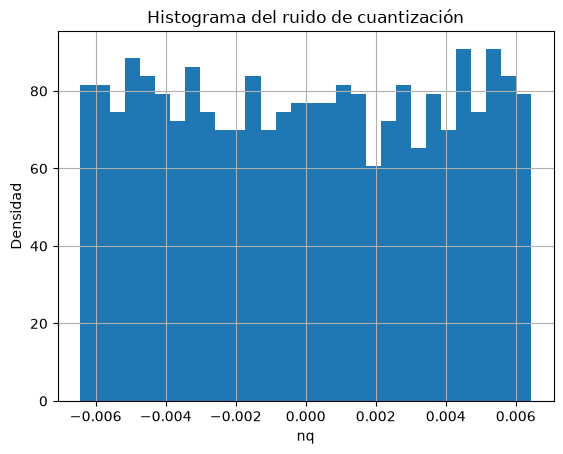

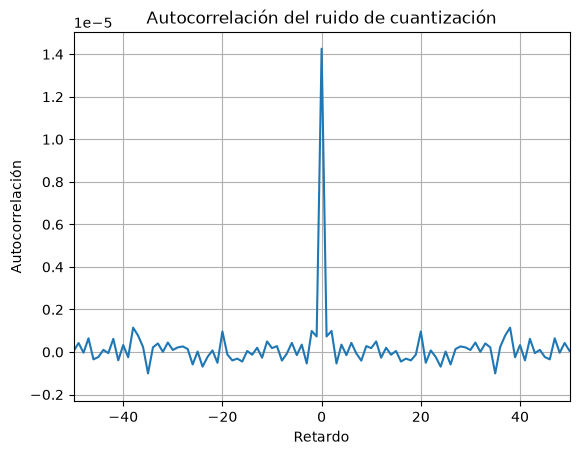

Estadístico D = 0.014494389437669786
p-valor = 0.9826675765066663
Como p-valor > 0.05, no rechazamos H0: el ruido de cuantizacion es compatible con una distribucion uniforme.


In [1]:
# -*- coding: utf-8 -*-
"""
Created on Thu Aug 27 20:31:09 2026

@author: Daniela Rolando 
"""


#%% IMPORTACION DE MODULOS 

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats 

#%% DEFINICION CTES

fs = 1000            # Frecuencia muestreo (Hz)
N = 1000             # Cant. muestras
Vmax = np.sqrt(2)    # Amplitud maxima
dc = 0               # Offset
ff = 3               # Frecuencia sinusoidal (Hz)
ph = 0               # Fase [rad]
SNR = 40             # SNR [dB]
Psen = 1             # Potencia media senoide [Watt]
ur = 0               # Media del ruido

k = 4
delta_f = 1

#ADC
B = 8 #Bits
#tenemos que lograr el efecto de la cuantizacionde atravesar un ADC
Vfs = 1.65 #Volts
qq = 2* Vfs /(2**B)


#%% FUNCIONES 

# Generador de señal senoidal
def gen_sin(Vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):

    # Genero un vector de valores de 0 a N/fs segundos
    # a intervalos de 1/fs
    tt = np.arange(0, stop=nn/fs, step=1/fs)

    # Genero un vector con los valores de la señal senoidal
    xx = dc + Vmax * np.sin(2 * np.pi * ff * tt + ph)

    return tt, xx


# Generador de ruido
def gen_noise(SNR=SNR, Psen=Psen, ur=ur, nn=N):

    # Despejo la potencia del ruido en función de SNR y Psen
    Pr = Psen / (10**(SNR/10))

    # Calculo la desviación estándar del ruido
    # en base a Pr (Pr = sigma^2)
    desv_est_r = np.sqrt(Pr)

    # Genero un vector de números aleatorios
    # de distribución normal
    ruido = np.random.normal(ur, desv_est_r, nn)

    return ruido


#%% MAIN SCRIPT

# Invoco la función generadora de senoides
tt, xx = gen_sin(Vmax, dc, ff, ph, N, fs)

# Invoco la función generadora de ruido
ruido = gen_noise(SNR, Psen, ur, N)

# Armo manualmente la señal ruidosa
noisy_xx = xx + ruido

# Armo vector de frecuencia
frec = np.arange(N//2) * fs/N

# Calculo fft de la señal ruidosa
nXX = 1/N * np.fft.fft(noisy_xx)

plt.close('all')
#plt.figure(1)
#plt.clf()

# Espectro del módulo
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

ax1.plot(frec, 10 * np.log10( 2*(np.abs(nXX[:N//2]))**2))  #inicialmente teniamos 20log, hacemos 10log e para poder tener en vez de raiz de dos sobre dos, tener 1/2 
ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_ylabel("Módulo dB")
ax1.grid(True)


# Segundo subplot: fase
ax2.plot(frec, np.angle(nXX[:N//2]))
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Fase [rad]")
ax2.grid(True)


# Ajustar layout para que no se superpongan
plt.tight_layout()
plt.show()


# CUANTIZAMOS

# xx cuantizada
xx_q = np.round(noisy_xx / qq)* qq

#ruido de cuantizacion
nq = xx_q - noisy_xx


plt.figure()
plt.plot(noisy_xx, ':x')
plt.plot(xx_q, ':v')
plt.title('Señal cuantizada')
plt.grid(True)
plt.show()


plt.figure()
plt.plot(nq/qq, ':x')
plt.title('Ruido de cuantización')
plt.xlabel('Muestra')
plt.xlabel('Ruido de cuantización [qq]')
plt.grid(True)
plt.show()


# tiene que estar entre los limites +- nq/2

#plt.plot(nq/qq,':x')

#esta tendría los limites en +- 1/2


#CONSIGNAS: Visualizar que el ruido de cuantizacion sigue una distribucion uniforme y que el ruido de cuantizacion nq es incorrelado (que su autocorrelacion es una delta)

#Como verificamos que el ruido es uniforme?
# ver la varianza. Tenemos q comprobar que la varianza del ruido de q al cuadrado sobre 12 
#la potencia del ruido se ve como np.var y si la distribucion es uniforme deberia ser parecido a q al cuadrado entre 12
#para verificar que la variable fue distribuida con distribucion uniforme podemos ver la densidad de probabilidad haciendo unaestimacion de la densidad, que se hace calculando el histograma
# el histograma se hace con click derecho en la variable (nq en este caso) y pulsando histograma
# el valor medio de nq tiene que dar mas o menos 0 


# comprobamos el valor medio
media_nq = np.mean(nq)

print("Media del ruido de cuantizacion:")
print(media_nq)


# comprobamos la varianza
var_nq = np.var(nq)

# valor teorico de la varianza
var_teorica = qq**2 / 12

print("Varianza del ruido de cuantizacion:")
print(var_nq)

print("q^2/12:")
print(var_teorica)


# histograma para ver la distribucion del ruido de cuantizacion
plt.figure()
plt.hist(nq, bins=30, density=True)
plt.title('Histograma del ruido de cuantización')
plt.xlabel('nq')
plt.ylabel('Densidad')
plt.grid(True)
plt.show()



#pero revisar un estimador no es suficiente. Hay que hacer un test de hipotesis. Ahora lo que necesitariamos preguntar es: bueno tengo una coleccion de 1000 muestras,dime la probabilidad de que hayan sido distribuidas de manera uniforme 
# entonces como puedo calcular un valor para poder rechazar la posibilidad de que no se hayan hecho mediante distribucion uniforme 
# habria que preguntar: buscamos un p valo que nos indique la probabilidad de la hipotesis nula de que esas muestras no se hayan sacado mediante distribucion uniforme


# Como podemos ver que sea incorrelado? 

# Hay que calcular la autocorrelacion y en la demora 0 tienes q encontrar la potencia media y para todos los demas lugares tiene q tender rapidamente a 0 porque tiene q ser como una delta.


# calculamos la autocorrelacion
autocorr = np.correlate(nq, nq, mode='full')

# normalizamos
autocorr = autocorr / N

# vector de retardos
lags = np.arange(-N + 1, N)

plt.figure()
plt.plot(lags, autocorr)
plt.title('Autocorrelación del ruido de cuantización')
plt.xlabel('Retardo')
plt.ylabel('Autocorrelación')
plt.xlim(-50, 50)
plt.grid(True)
plt.show()


plt.show()

#Calcular el pvalor 

# Uso el Test de Kolmogorov-Smirnov para comprobar uniformidad

D, pvalor = stats.kstest(
    nq,
    'uniform',
    args=(-qq/2, qq)
)

print("Estadístico D =", D)
print("p-valor =", pvalor)

print("Como p-valor > 0.05, no rechazamos H0: el ruido de cuantizacion es compatible con una distribucion uniforme.")




plt.show()